In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/python_course/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
!{sys.executable} -m pip install seaborn

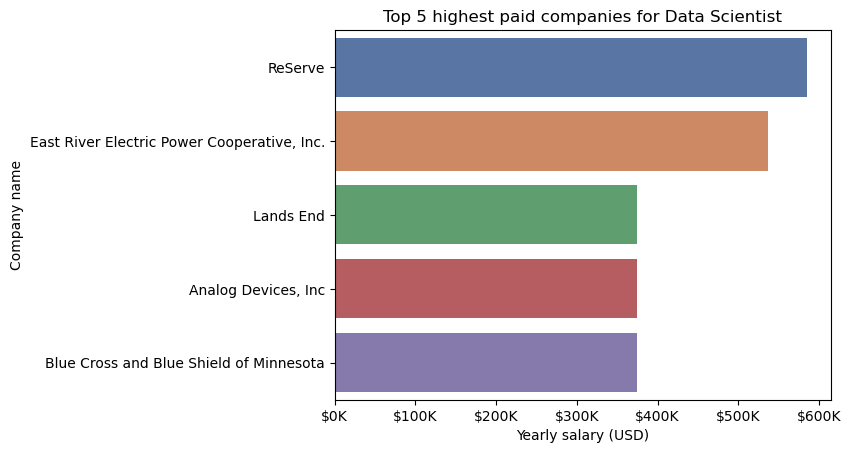

In [ ]:
import seaborn as sns

#Only get the Data scientist job in the US
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()

#Select top 5 high pay
df_DS_US_top5 = df_DS_US.groupby('company_name')['salary_year_avg'].agg(['median']).sort_values(by ='median', ascending = False)
df_DS_US_top5 = df_DS_US_top5.head(5)

#Import Funcformatter to add $ before the number
from matplotlib.ticker import FuncFormatter
#ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

#Create figure and ax
fig, ax = plt.subplots()

#Create barplot
sns.barplot(data = df_DS_US_top5, x='median', y=df_DS_US_top5.index, hue = 'company_name', palette = 'deep')

plt.title('Top 5 highest paid companies for Data Scientist')
plt.ylabel('Company name')
plt.xlabel('Yearly salary (USD)')

# Add $ to y-axis
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K') 
plt.gca().xaxis.set_major_formatter(ticks_x)

In [19]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

import sys
!{sys.executable} -m pip install seaborn

(0.0, 700000.0)

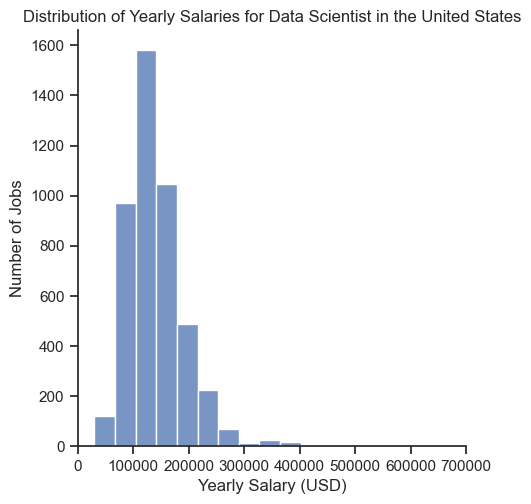

In [29]:
#Only get the Data scientist job in the US
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()

#Remove row with NA in salary_year_avg column
df_DS_US = df_DS_US.dropna(subset=['salary_year_avg'])

#Import Funcformatter to add $ before the number
from matplotlib.ticker import FuncFormatter
#ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

sns.displot(data = df_DS_US, x ='salary_year_avg', bins = 25)
plt.title('Distribution of Yearly Salaries for Data Scientist in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
plt.xlim(0, 700000)


In [30]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

import sys
!{sys.executable} -m pip install seaborn

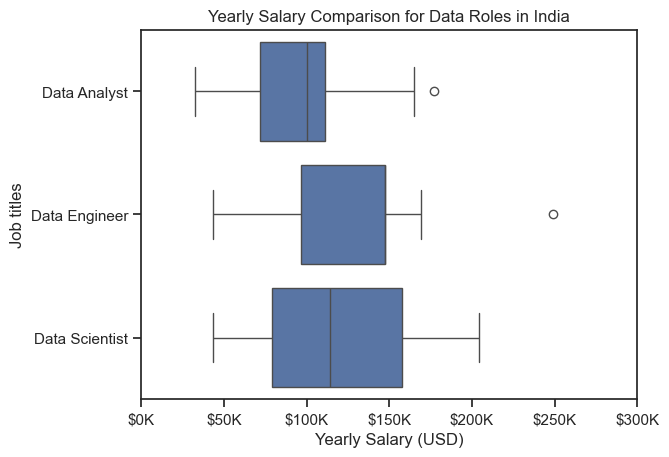

In [51]:
#Create dataframe containing job in India
df_IN = df[df['job_country'] == 'India'].copy()

#Create list of 3 job titles
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

#Create a sub-dataframe from each job titles
df_IN_list = [df_IN[df_IN['job_title_short'] == job_title] for job_title in job_titles]

# Create horizontal box plot
sns.boxplot(
    data=df_IN,
    x='salary_year_avg',
    y='job_title_short',
    order=job_titles
)

#set x-axis limit
plt.xlim(0, 300000)

# Format x-axis as $100K
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

plt.title('Yearly Salary Comparison for Data Roles in India')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Job titles')
plt.show()


In [52]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

import sys
!{sys.executable} -m pip install seaborn

Text(0.5, 0, '')

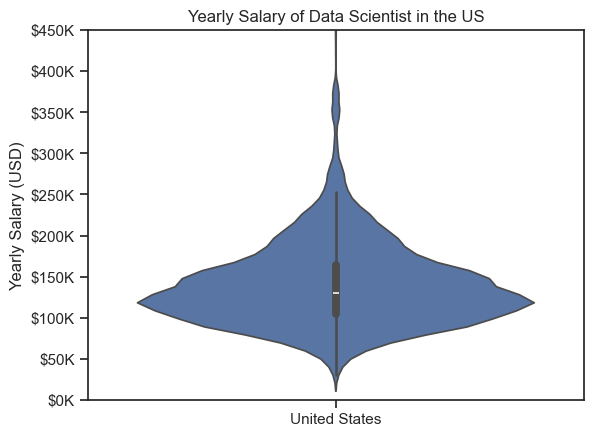

In [60]:
#Only get the Data scientist job in the US
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()

#Remove row with NA in salary_year_avg column
df_DS_US = df_DS_US.dropna(subset=['salary_year_avg'])

#Create Violin plot
sns.violinplot(data = df_DS_US, x='job_country', y='salary_year_avg') 

#set y-axis limit
plt.ylim(0, 450000)

# Format y-axis as $100K
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'${y/1000:.0f}K'))


plt.title('Yearly Salary of Data Scientist in the US')
plt.ylabel('Yearly Salary (USD)')
plt.xlabel('')

